1. Preprocesamiento y Balanceo del Dataset
Para cumplir con los requisitos del laboratorio ($m \ge 50000$, $n \ge 40$), utilizamos las características de audio de las canciones. Como el dataset original es de regresión y está desbalanceado, se seleccionaron los 10 años con mayor cantidad de registros.
Utilizando Pandas, se extrajeron exactamente **5,000 ejemplos aleatorios de cada año**, garantizando un dataset final de 50,000 registros perfectamente balanceado entre sus 10 clases.texto en negrita

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Cargando y procesando el dataset...")
# Cargar el archivo
df = pd.read_csv('YearPredictionMSD.csv', header=None)

# 1. Contar cuántas canciones hay por cada año
conteo_años = df[0].value_counts()

# 2. Filtrar SOLO los años que tengan estrictamente 5000 canciones o más
años_validos = conteo_años[conteo_años >= 5000].index

# 3. De esos años válidos, tomar los 10 que tengan mayor cantidad
top_10_years = conteo_años.loc[años_validos].nlargest(10).index

# 4. Filtrar el dataset original para quedarnos solo con esos 10 años
df_filtrado = df[df[0].isin(top_10_years)]

# 5. Balanceo estricto: Tomar exactamente 5000 ejemplos por cada clase
df_balanceado = df_filtrado.groupby(0).sample(n=5000, random_state=42)

# 6. Separar "y" (año) y "X" (características de audio)
y_raw = df_balanceado[0].values
X_raw = df_balanceado.drop(columns=[0]).values

# 7. Mapear los años reales a índices de clase (0 al 9)
clases_unicas = np.sort(np.unique(y_raw))
diccionario_clases = {val: idx for idx, val in enumerate(clases_unicas)}
y = np.array([diccionario_clases[val] for val in y_raw])

filas, columnas = X_raw.shape
num_clases = len(clases_unicas)

print(f"✅ Dataset balanceado con éxito.")
print(f"Registros (m): {filas} (Cumple requisito >= 50000)")
print(f"Características (n): {columnas} (Cumple requisito >= 40)")
print(f"Clases a predecir: {num_clases} años distintos -> {clases_unicas}")

Cargando y procesando el dataset...
✅ Dataset balanceado con éxito.
Registros (m): 50000 (Cumple requisito >= 50000)
Características (n): 90 (Cumple requisito >= 40)
Clases a predecir: 10 años distintos -> [2000 2001 2002 2003 2004 2005 2006 2007 2008 2009]


## 2. Partición de Datos (80/20) y Normalización Z-Score
Se realiza la división del dataset asignando el 80% (40,000 registros) exclusivamente para el entrenamiento y el 20% (10,000 registros) para validación. La media y desviación estándar para normalizar todas las características se obtienen únicamente del conjunto de entrenamiento para evitar el *data leakage*. Finalmente, agregamos la columna de unos ($X_0$).**texto en negrita**

In [5]:
# 1. Partición 80/20
m = len(y)
train_size = int(0.8 * m)
indices = np.arange(m)
np.random.seed(42) # Semilla para reproducibilidad
np.random.shuffle(indices)

X_train = X_raw[indices][:train_size]
y_train = y[indices][:train_size]
X_test = X_raw[indices][train_size:]
y_test = y[indices][train_size:]

# 2. Normalización Z-score
mu = np.mean(X_train, axis=0)
sigma = np.std(X_train, axis=0)
sigma[sigma == 0] = 1 # Prevenir división por cero

X_train_norm = (X_train - mu) / sigma
X_test_norm = (X_test - mu) / sigma

# 3. Columna de intersección (X0 = 1)
X_train_final = np.concatenate([np.ones((X_train_norm.shape[0], 1)), X_train_norm], axis=1)
X_test_final = np.concatenate([np.ones((X_test_norm.shape[0], 1)), X_test_norm], axis=1)

print(f"Matriz de Entrenamiento: {X_train_final.shape}")
print(f"Matriz de Prueba: {X_test_final.shape}")

Matriz de Entrenamiento: (40000, 91)
Matriz de Prueba: (10000, 91)


## 3. Implementación: Regresión Logística Multiclase (One-vs-All)
Para la clasificación multiclase, implementamos la estrategia "Uno contra Todos". Se entrenarán 10 modelos de regresión logística independientes (uno por cada clase). Cada modelo calculará la probabilidad de que una pista pertenezca a un año específico frente a todos los demás, minimizando el costo mediante el Descenso por el Gradiente.

In [9]:
def sigmoide(z):
    return 1 / (1 + np.exp(-z))

def calcularCosto(X, y, theta):
    m = len(y)
    h = sigmoide(np.dot(X, theta))
    epsilon = 1e-15 # Evitar log(0)
    h = np.clip(h, epsilon, 1 - epsilon)
    costo = - (1 / m) * np.sum(y * np.log(h) + (1 - y) * np.log(1 - h))
    return costo

def descensoGradiente(X, y, theta, alpha, num_iters):
    m = len(y)
    J_history = np.zeros(num_iters)
    theta = theta.copy()

    for i in range(num_iters):
        h = sigmoide(np.dot(X, theta))
        gradiente = (1 / m) * np.dot(X.T, (h - y))
        theta = theta - alpha * gradiente
        J_history[i] = calcularCosto(X, y, theta)

    return theta, J_history

## 4. Entrenamiento de Múltiples Clasificadores y Gráficas de Costo
A continuación, se entrena la matriz de parámetros $\theta$. Generamos 10 vectores $\theta$ distintos y almacenamos sus historiales de costo para visualizar cómo el algoritmo converge de manera efectiva en cada una de las clases.

Entrenando modelos One-vs-All...


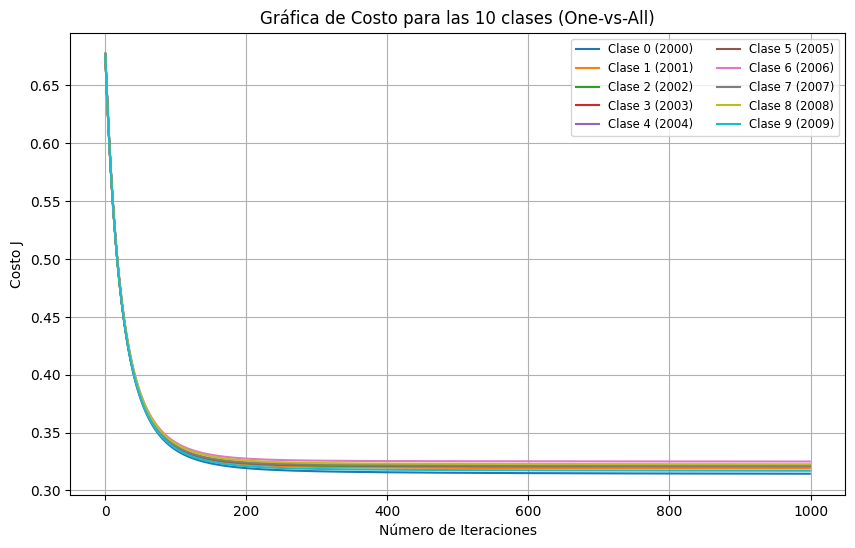

✅ Entrenamiento de los 10 modelos completado.


In [7]:
alpha = 0.1
iteraciones = 1000
all_theta = np.zeros((num_clases, X_train_final.shape[1]))

plt.figure(figsize=(10, 6))

print("Entrenando modelos One-vs-All...")
for c in range(num_clases):
    # Convertir 'y' a binario para la clase actual: 1 si es la clase 'c', 0 si no
    y_c = (y_train == c).astype(int)
    theta_inicial = np.zeros(X_train_final.shape[1])

    theta_optimizado, historial_J = descensoGradiente(X_train_final, y_c, theta_inicial, alpha, iteraciones)

    # Guardamos los parámetros entrenados en la fila 'c'
    all_theta[c] = theta_optimizado

    # Graficamos la convergencia de cada clase
    plt.plot(np.arange(iteraciones), historial_J, label=f'Clase {c} ({clases_unicas[c]})')

plt.xlabel('Número de Iteraciones')
plt.ylabel('Costo J')
plt.title('Gráfica de Costo para las 10 clases (One-vs-All)')
plt.legend(loc='upper right', fontsize='small', ncol=2)
plt.grid(True)
plt.show()

print("✅ Entrenamiento de los 10 modelos completado.")

## 5. Predicción, Validación y Precisión Final
Para clasificar los 10,000 datos de prueba, calculamos la probabilidad que emite cada uno de los 10 modelos entrenados. La predicción final corresponderá a la clase (año) que obtenga la probabilidad más alta. Finalmente, calculamos el porcentaje de exactitud general.

In [8]:
# 1. Generar predicciones para el set de prueba
def predecir_OneVsAll(X, all_theta):
    # Calculamos la probabilidad de cada clase (X multiplicado por all_theta transpuesto)
    probabilidades = sigmoide(np.dot(X, all_theta.T))
    # Nos quedamos con el índice (clase) que tenga la probabilidad máxima en cada fila
    predicciones = np.argmax(probabilidades, axis=1)
    return predicciones

y_pred_test = predecir_OneVsAll(X_test_final, all_theta)

# 2. Calcular la Efectividad / Precisión
exactitud = np.mean(y_pred_test == y_test) * 100

print(f"--- RESULTADOS DE LA VALIDACIÓN ---")
print(f"Datos evaluados (20%): {len(y_test)}")
print(f"Predicciones correctas: {np.sum(y_pred_test == y_test)}")
print(f"---------------------------------------------")
print(f"Precisión del Modelo Multiclase: {exactitud:.2f}%")
print(f"---------------------------------------------")

print("\nEjemplo de las primeras 15 predicciones vs Valores Reales:")
for i in range(15):
    año_real = clases_unicas[y_test[i]]
    año_predicho = clases_unicas[y_pred_test[i]]
    print(f"Instancia {i+1:02d} | Año Real: {año_real} | Predicción IA: {año_predicho}")

--- RESULTADOS DE LA VALIDACIÓN ---
Datos evaluados (20%): 10000
Predicciones correctas: 1332
---------------------------------------------
Precisión del Modelo Multiclase: 13.32%
---------------------------------------------

Ejemplo de las primeras 15 predicciones vs Valores Reales:
Instancia 01 | Año Real: 2001 | Predicción IA: 2005
Instancia 02 | Año Real: 2000 | Predicción IA: 2002
Instancia 03 | Año Real: 2006 | Predicción IA: 2000
Instancia 04 | Año Real: 2006 | Predicción IA: 2007
Instancia 05 | Año Real: 2008 | Predicción IA: 2008
Instancia 06 | Año Real: 2007 | Predicción IA: 2001
Instancia 07 | Año Real: 2003 | Predicción IA: 2002
Instancia 08 | Año Real: 2009 | Predicción IA: 2008
Instancia 09 | Año Real: 2006 | Predicción IA: 2009
Instancia 10 | Año Real: 2002 | Predicción IA: 2009
Instancia 11 | Año Real: 2002 | Predicción IA: 2000
Instancia 12 | Año Real: 2003 | Predicción IA: 2009
Instancia 13 | Año Real: 2002 | Predicción IA: 2000
Instancia 14 | Año Real: 2001 | Predic